# 🏎️ 🏁 Predicting Formula 1 Race Winners
#### CMSC320 | Spring 2026 Final Project
Arshad Sumarno, Jeffrey Osei, Rishi Gullipalli, Remy Eidelman, Jiming Chen, Daniel Louis

## **Contributions**

| Member  | Sections | 1-2 sentence summary |
|---------|----------|----------------------|
| Arshad Sumarno | B, C| Wrote introduction; Handled some data cleaning; Completed EDA with summary statistics |
| Jeffrey Osei | D, E, G| Contributed to data curation; Trained, tested, and analyzed SVM model|
| Rishi Gullipalli |F| Wrote Conclusion|
| Remy Eidelman | A, F | Helped develop idea and find dataset, worked on some prelim data preprocessing, did visualization section and worked on primary analysis|
| Jiming Chen | A, B | Sourced and organized the Kaggle F1 dataset; added data validation|
| Daniel Louis | D, E | Worked on the Random Classifier Model in primary analysis|

## **Introduction**

[Formula 1 Racing](https://www.formula1.com/) is a popular sporting event where around 22 racers from 22 different countries come together to compete for the Formula 1 World Drivers' Championship Trophy. In this project we will explore what career-level traits distinguish Formula 1 drivers who have won at least one race from drivers who never won.

**Essentially, can we predict whether a driver becomes is a race winner based on their career statistics?**

The applications of the findings of this project can provide crucial insight into the commonalities between race winners and what separates a winner vs. a non winner. Our conclusions can have impacts on predictive betting markets as well as car constructors who seek to understand the qualities that define a  winner. This analysis extends beyond a simple understanding of the features that can predict race winners and has implications for the sport as a whole. The relationship between computer science and athletics in general have become increasingly important as we have moved towards data driven sporting decisions. This investigation aims to develop models that can provide predictive insight for data scientists, constructors, and F1 fans.

## **Data Curation**

In this step of the data science life cycle, we must find and clean the data that is relevant for this research question. We will be using a dataset from Kaggle which contains historical F1 data about drivers, races, constructors, lap times, and finishing status.

Since F1 may be an unfamiliar topic, some terms must be defined before beginning:

*   **Constructor**: the team that builds and runs the car such as Mercedes or Ferrari
*   **Podium**: the driver finishes in the top three
*   **DNF**: "Did Not Finish"; the driver did not complete the race due to a number of reasons
*   **Mechanical Failure**: the driver did not finish the race due to an issue related to the car
*   **Points Scorer**: the driver finished high enough in a race to earn championship points
*   **Race Entry**: the number of appearances a driver has made. For example, if a driver competed in 10 races in one season, this would count as 10 race entries

In this section, we will clean and merge the csv files given in [this](https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020?select=drivers.csv) Kaggle dataset into one driver-level dataset with all the necessary features required to answer the research question. The final target variable will be `race_winner`, which signifies if an individual has won at least one F1 race.

This dataset provides rich statistics on drivers, constructors, and circuits dating back to 1950. Since we are interested in individual drivers and their career statistics, the data curation process will clean, calculate, and create a final dataframe with the features we are interested in utilizing in our predictive model. Some of these statistics include career length, DNF information, and podium-related statistics.

> It is important to note that while lap time may seem crucial conceptually, we have omitted it from our model because accurate data was not collected for a significant portion of F1 history. As such, most drivers in the dataset will not have lap time data.

#### Imports

In [ ]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
import numpy as np
import seaborn as sns
from dateutil import parser
import string
from datetime import datetime
from kagglehub import KaggleDatasetAdapter
from scipy import stats
from scipy.stats import norm
from scipy.stats import chi2_contingency
from statsmodels.stats.weightstats import ztest as ztest
from scipy.linalg import fractional_matrix_power
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score
from sklearn.svm import SVC
from sklearn.calibration import CalibrationDisplay
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [ ]:
file_path1 = "lap_times.csv"
file_path2 = "pit_stops.csv"
file_path3 = "drivers.csv"
file_path4 = "constructor_standings.csv"
file_path5 = "constructors.csv"
file_path6 = "races.csv"
file_path7 = "results.csv"
file_path8 = "status.csv"


# Load the latest versions of the datasets
lap_times_df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "rohanrao/formula-1-world-championship-1950-2020", file_path1)
pit_stops_df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "rohanrao/formula-1-world-championship-1950-2020", file_path2)
drivers_df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "rohanrao/formula-1-world-championship-1950-2020", file_path3)
constructor_standings_df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "rohanrao/formula-1-world-championship-1950-2020", file_path4)
constructors_df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "rohanrao/formula-1-world-championship-1950-2020", file_path5)
races_df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "rohanrao/formula-1-world-championship-1950-2020", file_path6)
results_df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "rohanrao/formula-1-world-championship-1950-2020", file_path7)
status_df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "rohanrao/formula-1-world-championship-1950-2020", file_path8)

100%|██████████| 16.8M/16.8M [00:00<00:00, 128MB/s]


Using Colab cache for faster access to the 'formula-1-world-championship-1950-2020' dataset.
Using Colab cache for faster access to the 'formula-1-world-championship-1950-2020' dataset.
Using Colab cache for faster access to the 'formula-1-world-championship-1950-2020' dataset.
Using Colab cache for faster access to the 'formula-1-world-championship-1950-2020' dataset.
Using Colab cache for faster access to the 'formula-1-world-championship-1950-2020' dataset.
Using Colab cache for faster access to the 'formula-1-world-championship-1950-2020' dataset.
Using Colab cache for faster access to the 'formula-1-world-championship-1950-2020' dataset.


#### Clean Data

In [ ]:
def replace_missing_placeholders(df):
    return df.replace("\\N", np.nan)

drivers_clean = replace_missing_placeholders(drivers_df.copy())
results_clean = replace_missing_placeholders(results_df.copy())
races_clean = replace_missing_placeholders(races_df.copy())
constructors_clean = replace_missing_placeholders(constructors_df.copy())
status_clean = replace_missing_placeholders(status_df.copy())

drivers_clean["driver_name"] = (
    drivers_clean["forename"].astype(str).str.strip()
    + " "
    + drivers_clean["surname"].astype(str).str.strip()
)

drivers_clean["dob"] = pd.to_datetime(drivers_clean["dob"], errors="coerce")

# keep relevant driver data
drivers_features = [
    "driverId",
    "driverRef",
    "number",
    "code",
    "forename",
    "surname",
    "driver_name",
    "dob",
    "nationality",
    "url"
]

drivers_clean = drivers_clean[drivers_features]

# clean and rename races data
races_clean["date"] = pd.to_datetime(races_clean["date"], errors="coerce")

races_clean = races_clean.rename(columns={
    "name": "race_name",
    "url": "race_url"
})

races_features = [
    "raceId",
    "year",
    "round",
    "circuitId",
    "race_name",
    "date",
    "race_url"
]

races_clean = races_clean[races_features]

# clean and rename constructor data
constructors_clean = constructors_clean.rename(columns={
    "name": "constructor_name",
    "nationality": "constructor_nationality",
    "url": "constructor_url"
})

constructors_features = [
    "constructorId",
    "constructorRef",
    "constructor_name",
    "constructor_nationality",
    "constructor_url"
]

constructors_clean = constructors_clean[constructors_features]

# clean and rename status data
status_clean = status_clean.rename(columns={
    "status": "finish_status"
})

# merge on results we need
results_features = [
    "resultId",
    "raceId",
    "driverId",
    "constructorId",
    "grid",
    "position",
    "positionText",
    "positionOrder",
    "points",
    "milliseconds",
    "rank",
    "statusId"
]

results_clean = results_clean[results_features]

race_results = (
    results_clean
    .merge(races_clean, on="raceId", how="left")
    .merge(drivers_clean, on="driverId", how="left")
    .merge(constructors_clean, on="constructorId", how="left")
    .merge(status_clean, on="statusId", how="left")
)

# create winning data
race_results["is_win"] = (race_results["positionOrder"] == 1).astype(int)
race_results["is_podium"] = (race_results["positionOrder"] <= 3).astype(int)
race_results["is_points_finish"] = (race_results["points"] > 0).astype(int)

# calculate dnf data
finished_statuses = [
    "Finished",
    "+1 Lap", "+2 Laps", "+3 Laps", "+4 Laps", "+5 Laps",
    "+6 Laps", "+7 Laps", "+8 Laps", "+9 Laps"
]

race_results["is_dnf"] = (~race_results["finish_status"].isin(finished_statuses)).astype(int)

# add age data
race_results["driver_age_at_race"] = (
    (race_results["date"] - race_results["dob"]).dt.days / 365.25
)

display(race_results.head())


,resultId,raceId,driverId,constructorId,grid,position,positionText,positionOrder,points,milliseconds,...,constructorRef,constructor_name,constructor_nationality,constructor_url,finish_status,is_win,is_podium,is_points_finish,is_dnf,driver_age_at_race
0,1,18,1,1,1,1,1,1,10.0,5690616,...,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,1,1,1,0,23.186858
1,2,18,2,2,5,2,2,2,8.0,5696094,...,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber,Finished,0,1,1,0,30.850103
2,3,18,3,3,7,3,3,3,6.0,5698779,...,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...,Finished,0,1,1,0,22.718686
3,4,18,4,4,11,4,4,4,5.0,5707797,...,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...,Finished,0,0,1,0,26.631075
4,5,18,5,1,3,5,5,5,4.0,5708630,...,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,0,0,1,0,26.406571


Before moving on, we run a quick sanity check on the merged dataframe to make sure no rows were dropped unexpectedly and key fields are populated.

In [ ]:
# sanity check the merged race_results
print(f"Total race result rows: {len(race_results):,}")
print(f"Unique drivers: {race_results['driverId'].nunique()}")
print(f"Unique races: {race_results['raceId'].nunique()}")
print(f"Year range: {race_results['year'].min()} - {race_results['year'].max()}")
print(f"Rows missing constructor: {race_results['constructor_name'].isna().sum()}")
print(f"Rows missing finish_status: {race_results['finish_status'].isna().sum()}")

Total race result rows: 26,759
Unique drivers: 861
Unique races: 1125
Year range: 1950 - 2024
Rows missing constructor: 0
Rows missing finish_status: 0


#### Calculate DNF and age related features

We want to calculate mechanical related DNFs in order to specifically understand why the driver did not finish the race. Having more mechanical related DNFs be better explained by constructor failure rather than lack of driver ability. This is an important distinction to make since we are interested in predicting drivers and would want to avoid unfairly penalizing them for driving worse cars.

In [ ]:
# get mechanical related dnfs
mechanical_statuses = [
    "Engine", "Transmission", "Clutch", "Electrical", "Hydraulics",
    "Gearbox", "Radiator", "Suspension", "Brakes", "Overheating",
    "Mechanical", "Tyre", "Puncture", "Driveshaft", "Fuel pressure",
    "Water pressure", "Wheel", "Throttle", "Steering", "Technical",
    "Electronics", "Heat shield fire", "Exhaust", "Oil leak",
    "Wheel rim", "Water leak", "Fuel pump", "Track rod", "Oil pressure",
    "Pneumatics", "Engine fire", "Tyre puncture", "Out of fuel",
    "Wheel nut", "Handling", "Fire", "Fuel system", "Oil line",
    "Fuel rig", "Launch control", "Fuel", "Power loss", "Drivetrain",
    "Ignition", "Chassis", "Battery", "Stalled", "Halfshaft",
    "Crankshaft", "Alternator", "Differential", "Wheel bearing",
    "Vibrations", "Oil pump", "Fuel leak", "Injection", "Distributor",
    "Turbo", "CV joint", "Water pump", "Spark plugs", "Fuel pipe",
    "Oil pipe", "Axle", "Water pipe", "Magneto", "Supercharger",
    "Engine misfire", "ERS", "Power Unit", "Brake duct", "Cooling system"
]

race_results["is_mechanical_dnf"] = (
    race_results["finish_status"].isin(mechanical_statuses).astype(int)
)

# get age at debut

driver_debut_age = (
    race_results
    .sort_values(["driverId", "date"])
    .groupby("driverId")
    .agg(
        debut_date=("date", "first"),
        date_of_birth=("dob", "first")
    )
    .reset_index()
)

driver_debut_age["age_at_debut"] = (
    (driver_debut_age["debut_date"] - driver_debut_age["date_of_birth"]).dt.days / 365.25
)

driver_debut_age = driver_debut_age[["driverId", "age_at_debut"]]

#### Merge results

In [ ]:
# one row per driver
driver_agg = (
    race_results
    .groupby("driverId")
    .agg(
        driver_name=("driver_name", "first"),
        driver_ref=("driverRef", "first"),
        nationality=("nationality", "first"),
        date_of_birth=("dob", "first"),

        first_year=("year", "min"),
        last_year=("year", "max"),
        first_race_date=("date", "min"),
        last_race_date=("date", "max"),

        total_entries=("raceId", "count"),

        total_wins=("is_win", "sum"),
        total_podiums=("is_podium", "sum"),
        total_points_finishes=("is_points_finish", "sum"),
        career_points=("points", "sum"),

        avg_points_per_race=("points", "mean"),
        avg_finish_position=("positionOrder", "mean"),
        median_finish_position=("positionOrder", "median"),
        best_finish_position=("positionOrder", "min"),

        total_dnfs=("is_dnf", "sum"),
        total_mechanical_dnfs=("is_mechanical_dnf", "sum"),
        avg_age_at_race=("driver_age_at_race", "mean"),

        race_count=("raceId", "nunique"),
        season_count=("year", "nunique")
    )
    .reset_index()
)

# calculate rates

driver_agg["career_length_years"] = driver_agg["last_year"] - driver_agg["first_year"] + 1
driver_agg["win_rate"] = driver_agg["total_wins"] / driver_agg["total_entries"]
driver_agg["podium_rate"] = driver_agg["total_podiums"] / driver_agg["total_entries"]
driver_agg["points_finish_rate"] = driver_agg["total_points_finishes"] / driver_agg["total_entries"]
driver_agg["points_per_entry"] = driver_agg["career_points"] / driver_agg["total_entries"]
driver_agg["dnf_rate"] = driver_agg["total_dnfs"] / driver_agg["total_entries"]
driver_agg["mechanical_dnf_rate"] = driver_agg["total_mechanical_dnfs"] / driver_agg["total_entries"]

# add age at debut
driver_agg = driver_agg.merge(
    driver_debut_age,
    on="driverId",
    how="left"
)

# create target variable
# 1 = driver won at least one race
# 0 = driver never won a race

driver_agg["race_winner"] = (driver_agg["total_wins"] > 0).astype(int)
driver_agg["podium_finisher"] = (driver_agg["total_podiums"] > 0).astype(int)

# career category labels

def classify_driver_success(row):
    if row["total_wins"] > 0:
        return "Race winner"
    elif row["total_podiums"] > 0:
        return "Podium finisher, no wins"
    elif row["career_points"] > 0:
        return "Points scorer, no podiums"
    else:
        return "No points"

driver_agg["success_group"] = driver_agg.apply(classify_driver_success, axis=1)

target_counts = driver_agg["race_winner"].value_counts().rename(index={0: "Non-winner", 1: "Race winner"})

# reorder columns

ordered_cols = [
    "driverId",
    "driver_name",
    "driver_ref",
    "nationality",
    "date_of_birth",

    "first_year",
    "last_year",
    "career_length_years",
    "season_count",
    "age_at_debut",

    "total_entries",
    "race_count",

    "total_wins",
    "total_podiums",
    "total_points_finishes",
    "career_points",

    "win_rate",
    "podium_rate",
    "points_finish_rate",
    "points_per_entry",
    "avg_points_per_race",

    "avg_finish_position",
    "median_finish_position",
    "best_finish_position",

    "total_dnfs",
    "dnf_rate",
    "total_mechanical_dnfs",
    "mechanical_dnf_rate",
    "avg_age_at_race",

    "race_winner",
    "podium_finisher",
    "success_group"
]

driver_agg = driver_agg[ordered_cols]

display(driver_agg.head())

,driverId,driver_name,driver_ref,nationality,date_of_birth,first_year,last_year,career_length_years,season_count,age_at_debut,...,median_finish_position,best_finish_position,total_dnfs,dnf_rate,total_mechanical_dnfs,mechanical_dnf_rate,avg_age_at_race,race_winner,podium_finisher,success_group
0,1,Lewis Hamilton,hamilton,British,1985-01-07,2007,2024,18,18,22.190281,...,3.0,1,34,0.095506,15,0.042135,31.430296,1,1,Race winner
1,2,Nick Heidfeld,heidfeld,German,1977-05-10,2000,2011,12,12,22.839151,...,10.0,2,49,0.266304,31,0.168478,28.228774,0,1,"Podium finisher, no wins"
2,3,Nico Rosberg,rosberg,German,1985-06-27,2006,2016,11,11,20.706366,...,7.0,1,31,0.150485,17,0.082524,26.210522,1,1,Race winner
3,4,Fernando Alonso,alonso,Spanish,1981-07-29,2001,2024,24,21,19.597536,...,7.0,1,79,0.195545,54,0.133663,31.909719,1,1,Race winner
4,5,Heikki Kovalainen,kovalainen,Finnish,1981-10-19,2007,2013,7,7,25.409993,...,14.0,1,24,0.214286,14,0.125000,28.402635,1,1,Race winner


We also verify the driver-level aggregation looks reasonable before moving into EDA.

In [ ]:
# sanity check the final driver-level dataframe
print(f"Total drivers: {len(driver_agg)}")
print(f"Race winners: {driver_agg['race_winner'].sum()}")
print(f"Non-winners: {(driver_agg['race_winner'] == 0).sum()}")
print(f"Drivers missing age_at_debut: {driver_agg['age_at_debut'].isna().sum()}")
print(f"Career length range: {driver_agg['career_length_years'].min()} - {driver_agg['career_length_years'].max()} years")

Total drivers: 861
Race winners: 115
Non-winners: 746
Drivers missing age_at_debut: 0
Career length range: 1 - 24 years


## **Exploratory Data Analysis**

In this section, we will graph the data in order to investigate any relationships that can be observed. We must evaluate the data that we have, the relevant features, and the relationships between these features. At the end, we create a correlational heatmap to understand how these features are related. Broken down, here is what our curated dataset looks like:

In [ ]:
display(driver_agg.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 861 entries, 0 to 860
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   driverId                861 non-null    int64         
 1   driver_name             861 non-null    object        
 2   driver_ref              861 non-null    object        
 3   nationality             861 non-null    object        
 4   date_of_birth           861 non-null    datetime64[ns]
 5   first_year              861 non-null    int64         
 6   last_year               861 non-null    int64         
 7   career_length_years     861 non-null    int64         
 8   season_count            861 non-null    int64         
 9   age_at_debut            861 non-null    float64       
 10  total_entries           861 non-null    int64         
 11  race_count              861 non-null    int64         
 12  total_wins              861 non-null    int64     

None

In [ ]:
display(driver_agg.describe())

,driverId,date_of_birth,first_year,last_year,career_length_years,season_count,age_at_debut,total_entries,race_count,total_wins,...,avg_finish_position,median_finish_position,best_finish_position,total_dnfs,dnf_rate,total_mechanical_dnfs,mechanical_dnf_rate,avg_age_at_race,race_winner,podium_finisher
count,861.000000,861,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000,...,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000
mean,431.061556,1941-09-24 08:28:25.923344896,1971.213705,1974.462253,4.248548,3.729384,29.939677,31.078978,30.973287,1.310105,...,16.606225,16.425087,10.146341,13.629501,0.618939,7.745645,0.285086,31.654342,0.133566,0.250871
min,1.000000,1896-12-28 00:00:00,1950.000000,1950.000000,1.000000,1.000000,17.453799,1.000000,1.000000,0.000000,...,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,18.146475,0.000000,0.000000
25%,216.000000,1923-01-11 00:00:00,1954.000000,1958.000000,1.000000,1.000000,25.002053,2.000000,2.000000,0.000000,...,12.107143,11.500000,3.000000,1.000000,0.406061,0.000000,0.000000,27.091581,0.000000,0.000000
50%,431.000000,1937-02-02 00:00:00,1965.000000,1968.000000,3.000000,2.000000,28.520192,7.000000,6.000000,0.000000,...,15.666667,15.000000,8.000000,4.000000,0.609756,2.000000,0.250000,30.653631,0.000000,0.000000
75%,646.000000,1957-11-27 00:00:00,1983.000000,1989.000000,6.000000,5.000000,33.623546,30.000000,30.000000,0.000000,...,20.000000,21.000000,14.000000,15.000000,1.000000,7.000000,0.428571,35.065480,0.000000,1.000000
max,862.000000,2005-05-08 00:00:00,2024.000000,2024.000000,24.000000,21.000000,53.637235,404.000000,404.000000,105.000000,...,38.833333,39.000000,38.000000,153.000000,1.000000,107.000000,1.000000,54.135524,1.000000,1.000000
std,248.793797,NaN,19.745493,20.626412,3.993718,3.551604,6.646833,56.264085,56.259970,6.786118,...,6.150049,6.713005,8.245193,21.572992,0.313771,13.949798,0.270691,6.301403,0.340383,0.433766


As a first step, we break down the data we have on the target variable: **winner vs. non-winner**

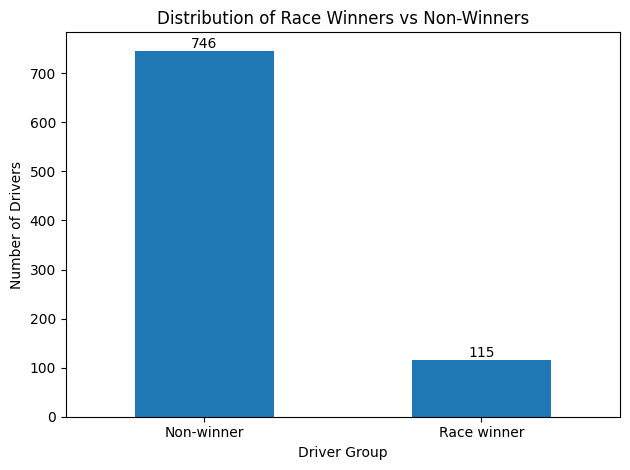


More detailed break down of non-winners:



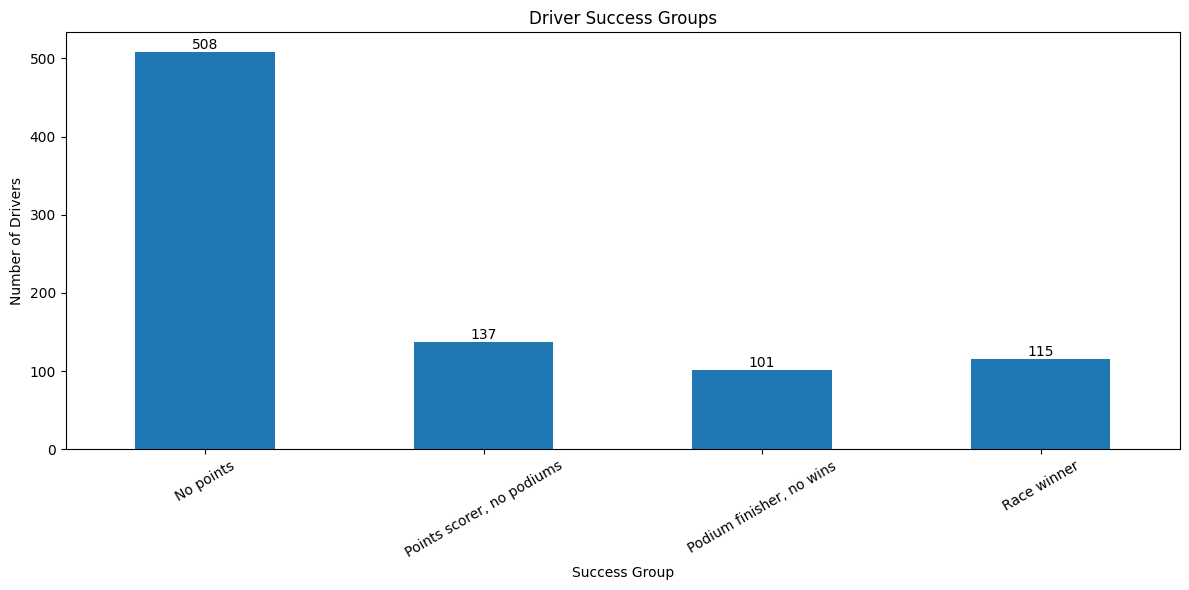

In [ ]:
# race winners vs. non-race winners

fig, ax = plt.subplots()

target_counts.plot(kind="bar", ax=ax)

ax.set_title("Distribution of Race Winners vs Non-Winners")
ax.set_xlabel("Driver Group")
ax.set_ylabel("Number of Drivers")
ax.tick_params(axis="x", rotation=0)

for i, value in enumerate(target_counts.values):
    ax.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()


# success group

success_order = [
    "No points",
    "Points scorer, no podiums",
    "Podium finisher, no wins",
    "Race winner"
]

success_counts = (
    driver_agg["success_group"]
    .value_counts()
    .reindex(success_order)
)

print()
print("More detailed break down of non-winners:")
print()

fig, ax = plt.subplots(figsize=(12, 6))

success_counts.plot(kind="bar", ax=ax)

ax.set_title("Driver Success Groups")
ax.set_xlabel("Success Group")
ax.set_ylabel("Number of Drivers")
ax.tick_params(axis="x", rotation=30)

for i, value in enumerate(success_counts.values):
    ax.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

From this breakdown, we can see in general there are much less race winners than there are non-winners. This makes sense in the context of the real world, where the majority of drivers have not won. Broken down into different relevant groups, we can see that there is not an even spread between the three types of non-winners:


*   **Points scorer, no podiums**: the driver finished high enough to score points during the race, but did not place in the top 3
*   **Podium finisher, no wins**: the driver finished in the top 3 but did not win the race
*   **No points**: the driver did not score any points during the race

There is an overwhelming majority of "no points" drivers, which also makes sense in this context because the majority of finishes in a race do not score points.

### Hypothesis Tests
Now, we can conduct our hypothesis tests. First, we will conduct a **T-Test** exploring the relationship between race winners, non-winners, and points per entry

**Null hypothesis** $H_{0}$:
Race winners and non-winners have the same mean `points_per_entry`.

**Alternative hypothesis** $H_{1}$:
Race winners and non-winners have different mean `points_per_entry`.

Race winners sample size: 115
Non-winners sample size: 746

Race winners mean points per entry: 2.6275
Non-winners mean points per entry: 0.1798

T-statistic: 10.8087
P-value: 0.00000000


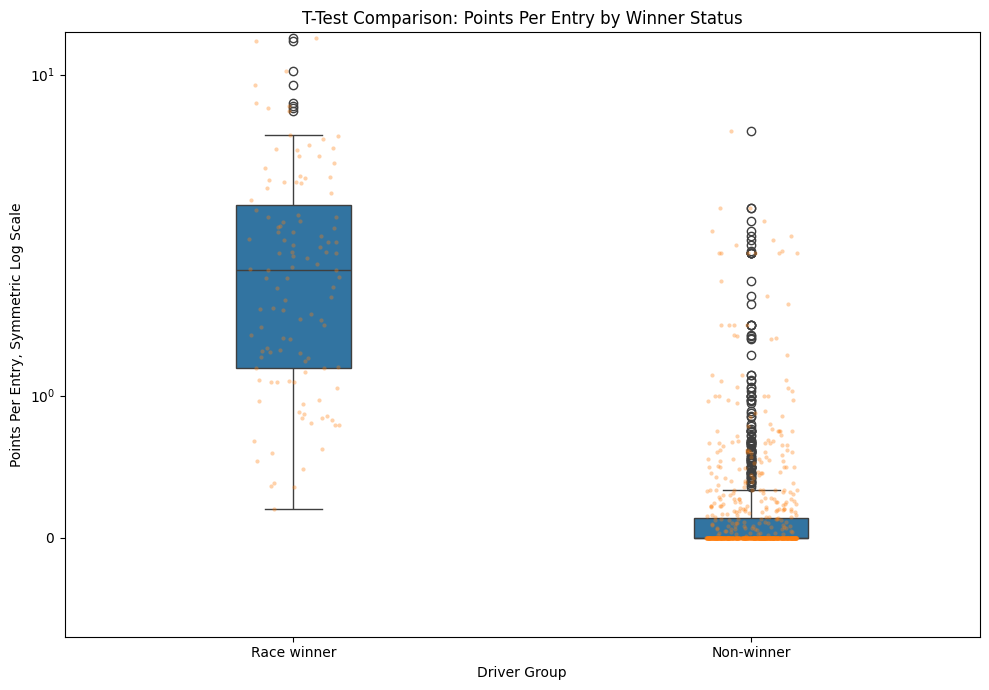

In [ ]:
# make eda df

eda_df = driver_agg.copy()

winner_points = eda_df.loc[
    eda_df["race_winner"] == 1,
    "points_per_entry"
].dropna()

nonwinner_points = eda_df.loc[
    eda_df["race_winner"] == 0,
    "points_per_entry"
].dropna()

eda_df["winner_group"] = np.where(
    eda_df["race_winner"] == 1,
    "Race winner",
    "Non-winner"
)

t_stat, t_p_value = stats.ttest_ind(
    winner_points,
    nonwinner_points,
    equal_var=False
)

print(f"Race winners sample size: {len(winner_points)}")
print(f"Non-winners sample size: {len(nonwinner_points)}")
print()
print(f"Race winners mean points per entry: {winner_points.mean():.4f}")
print(f"Non-winners mean points per entry: {nonwinner_points.mean():.4f}")
print()
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {t_p_value:.8f}")

# plot
fig, ax = plt.subplots(figsize=(10, 7))

sns.boxplot(
    data=eda_df,
    x="winner_group",
    y="points_per_entry",
    width=0.25,
    ax=ax
)

sns.stripplot(
    data=eda_df,
    x="winner_group",
    y="points_per_entry",
    alpha=0.35,
    jitter=True,
    size=3,
    ax=ax
)

ax.set_yscale("symlog")
ax.set_title("T-Test Comparison: Points Per Entry by Winner Status")
ax.set_xlabel("Driver Group")
ax.set_ylabel("Points Per Entry, Symmetric Log Scale")

plt.tight_layout()
plt.show()

Here, we see that the T-Test produced a p-value of 0, which is below 0.05. Therefore, we reject the null hypothesis and can conclude that there is statistically significant evidence that there is a difference in average points per entry between race winners and non-winners.

> We are using a symmetric log scale because the features are very skewed. Most drivers have low values, but a small number of drivers have extremely high values. Many values are most likely 0, which is why a symmetric log scale is needed.

This T-Test can lead us to the further conclusion that race winners tend to score more points per entry on average compared to non-winners.

Next, we will conduct a **Z-Test** to understand whether drivers who debuted before or after 1980 were more likely to become race winners. Here we will be comparing the proportion of race winners to non winners among the earlier era and the modern era. This is a useful question to ask because F1 has changed over time.

**Null hypothesis** $H_{0}$:
Race winners rates do not differ by debut year.

**Alternative hypothesis** $H_{1}$:
Race winners rates differ by debut year.

Modern-era race winners: 42 out of 238
Earlier-era race winners: 73 out of 623

Modern-era winner proportion: 0.1765
Earlier-era winner proportion: 0.1172

Z-statistic: 2.2874
P-value: 0.02217362


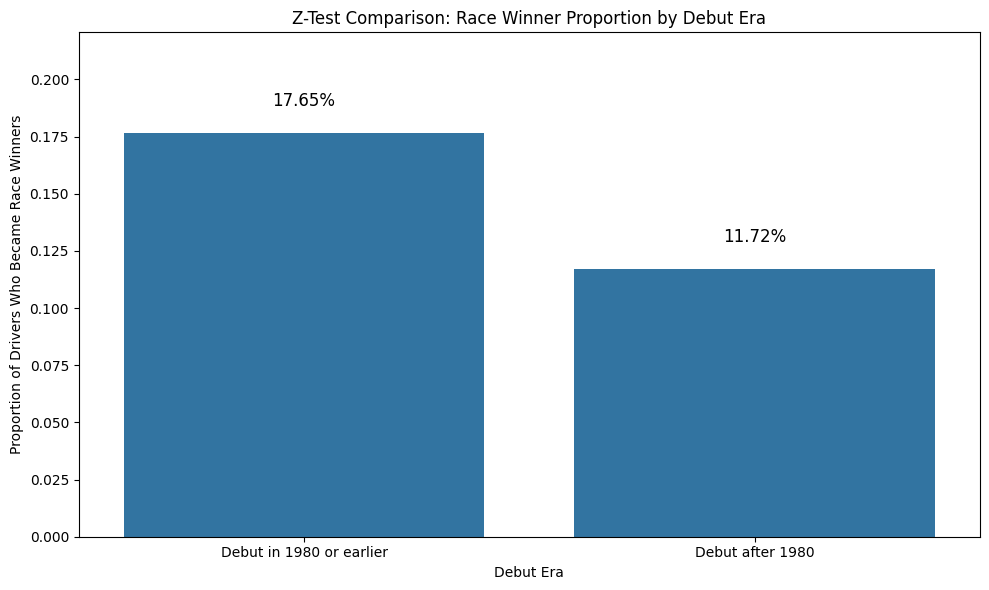

In [ ]:
# create debut era variable
eda_df["debut_era"] = np.where(
    eda_df["first_year"] > 1980,
    "Debut after 1980",
    "Debut in 1980 or earlier"
)

modern_group = eda_df[eda_df["debut_era"] == "Debut after 1980"]
early_group = eda_df[eda_df["debut_era"] == "Debut in 1980 or earlier"]

# number of race winners in each group
x1_era = modern_group["race_winner"].sum()
x2_era = early_group["race_winner"].sum()

n1_era = len(modern_group)
n2_era = len(early_group)

# Proportions
p1_era = x1_era / n1_era
p2_era = x2_era / n2_era

# pooled proportion
p_pool_era = (x1_era + x2_era) / (n1_era + n2_era)

# standard error
standard_error_era = np.sqrt(
    p_pool_era * (1 - p_pool_era) * ((1 / n1_era) + (1 / n2_era))
)

z_stat_era = (p1_era - p2_era) / standard_error_era

# two-tailed p-value
z_p_value_era = 2 * (1 - norm.cdf(abs(z_stat_era)))

print(f"Modern-era race winners: {x1_era} out of {n1_era}")
print(f"Earlier-era race winners: {x2_era} out of {n2_era}")
print()
print(f"Modern-era winner proportion: {p1_era:.4f}")
print(f"Earlier-era winner proportion: {p2_era:.4f}")
print()
print(f"Z-statistic: {z_stat_era:.4f}")
print(f"P-value: {z_p_value_era:.8f}")

# plot
era_z_plot_df = pd.DataFrame({
    "Debut Era": ["Debut in 1980 or earlier", "Debut after 1980"],
    "Race Winner Proportion": [p1_era, p2_era]
})

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=era_z_plot_df,
    x="Debut Era",
    y="Race Winner Proportion",
    ax=ax
)

ax.set_title("Z-Test Comparison: Race Winner Proportion by Debut Era")
ax.set_xlabel("Debut Era")
ax.set_ylabel("Proportion of Drivers Who Became Race Winners")
ax.set_ylim(0, max(era_z_plot_df["Race Winner Proportion"]) * 1.25)

for i, value in enumerate(era_z_plot_df["Race Winner Proportion"]):
    ax.text(
        i,
        value + 0.01,
        f"{value:.2%}",
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.tight_layout()
plt.show()

Here we can see that the p-value is 0.02 which is below 0.05. Therefore, we can reject the null hypothesis and conclude that the proportion of race winners differs between debut year by a statistically significant degree.

Finally, we can do an **ANOVA Test** to understand if the four success group categories have different average total entries. The aim of this question is to understand if drivers from different success groups tend to have a different number of race entries.

**Null hypothesis** $H_{0}$:
All success groups have the same mean `total_entries`

**Alternative hypothesis** $H_{1}$:
At least one success group has a different mean `total_entries`

No points: n = 508, mean = 5.6457, median = 2.0000
Points scorer, no podiums: n = 137, mean = 33.1314, median = 20.0000
Podium finisher, no wins: n = 101, mean = 49.9109, median = 29.0000
Race winner: n = 115, mean = 124.4435, median = 112.0000

F-statistic: 288.2876
P-value: 0.00000000


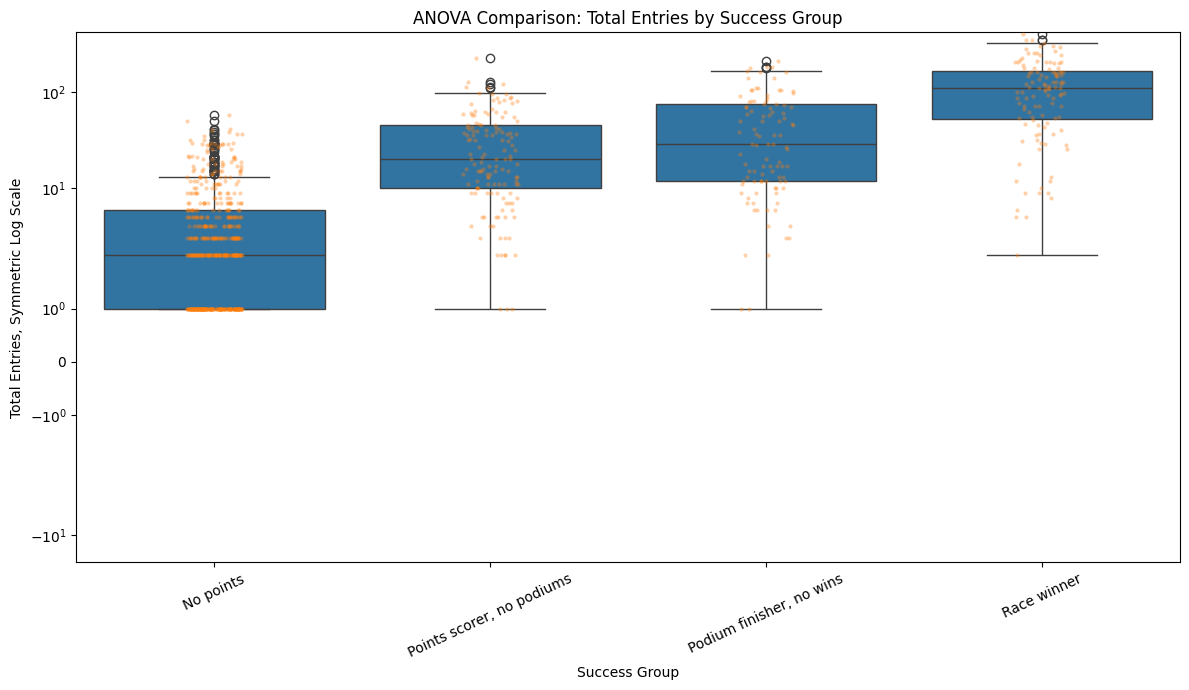

In [ ]:
anova_feature = "total_entries"

anova_groups = []

for group in success_order:
    group_data = eda_df.loc[
        eda_df["success_group"] == group,
        anova_feature
    ].dropna()

    anova_groups.append(group_data)

# one-way ANOVA
f_stat, anova_p_value = stats.f_oneway(*anova_groups)

for group, data in zip(success_order, anova_groups):
    print(f"{group}: n = {len(data)}, mean = {data.mean():.4f}, median = {data.median():.4f}")

print()
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {anova_p_value:.8f}")

# plot
fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=eda_df,
    x="success_group",
    y=anova_feature,
    order=success_order,
    ax=ax
)

sns.stripplot(
    data=eda_df,
    x="success_group",
    y=anova_feature,
    order=success_order,
    alpha=0.35,
    jitter=True,
    size=3,
    ax=ax
)

ax.set_yscale("symlog")
ax.set_title("ANOVA Comparison: Total Entries by Success Group")
ax.set_xlabel("Success Group")
ax.set_ylabel("Total Entries, Symmetric Log Scale")
ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

Since the ANOVA test produced a p-value of 0, we can reject the null hypothesis since it is below 0.05. Thus, we can conclude that there is statistically significant evidence that the average total entries are not the same across all success groups.

> We are using a symmetric log scale here for the same reason as detailed in the T-test

We also want to understand the differences between winners and non-winners as related to the features. For this, we can use a box and whisker plot to understand the differences across career length, total entries, finish position, and DNF rate.

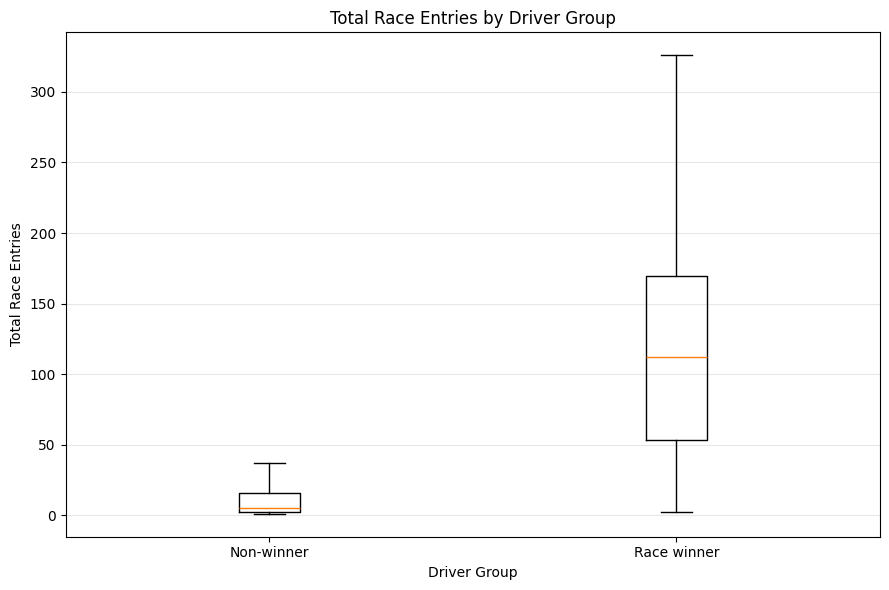

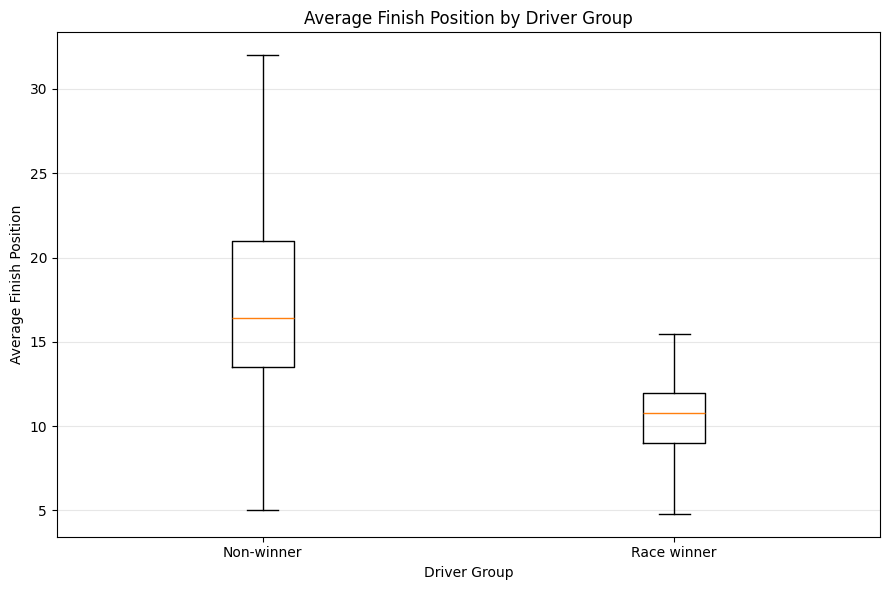

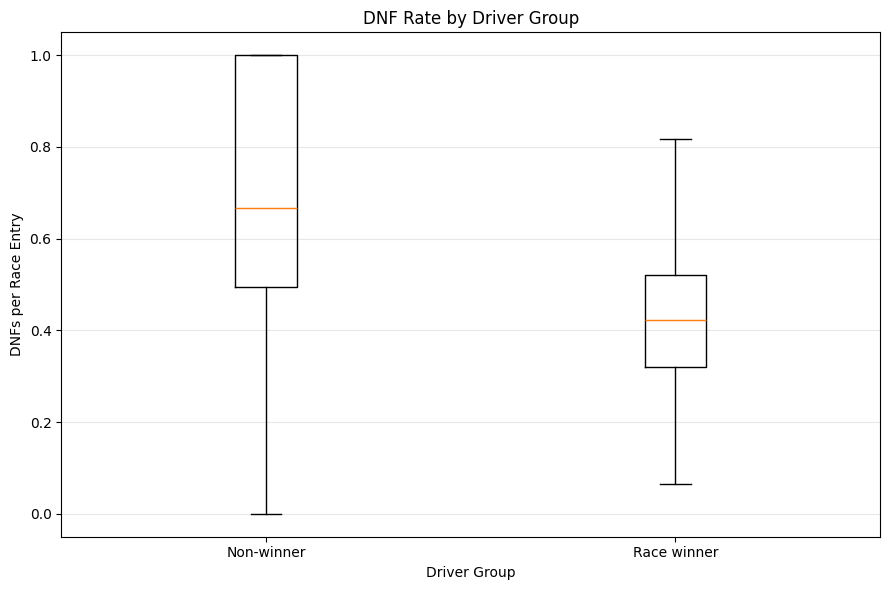

In [ ]:
# make eda df with race winner label

eda_df["winner_group"] = eda_df["race_winner"].map({
    0: "Non-winner",
    1: "Race winner"
})

# box plots between winners and non-winners

def make_group_boxplot(df, feature, title, ylabel):
    fig, ax = plt.subplots(figsize=(9, 6))

    groups = [
        df.loc[df["winner_group"] == "Non-winner", feature].dropna(),
        df.loc[df["winner_group"] == "Race winner", feature].dropna()
    ]

    ax.boxplot(
        groups,
        tick_labels=["Non-winner", "Race winner"],
        showfliers=False
    )

    ax.set_title(title)
    ax.set_xlabel("Driver Group")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

# total entries
make_group_boxplot(
    eda_df,
    "total_entries",
    "Total Race Entries by Driver Group",
    "Total Race Entries"
)

# average finish position (lower is better)

make_group_boxplot(
    eda_df,
    "avg_finish_position",
    "Average Finish Position by Driver Group",
    "Average Finish Position"
)

# dnf rate

make_group_boxplot(
    eda_df,
    "dnf_rate",
    "DNF Rate by Driver Group",
    "DNFs per Race Entry"
)

Here, we can begin to see some relationships between the features and the target variable. The box and whisker plots show that race winners generally have more race entries. In terms of average finish position and DNF rate, there is less of a difference, but we still see trends that make sense in the context of the real world. Race winners tend to finish closer to the top positions and have less DNFs.

We can also visualize the relationship between career length and success. To do so, we can split this up by success group in order to see more relationships in the hierarchies of success. We can use a violin plot to see the relationships of career length and the different categories of success

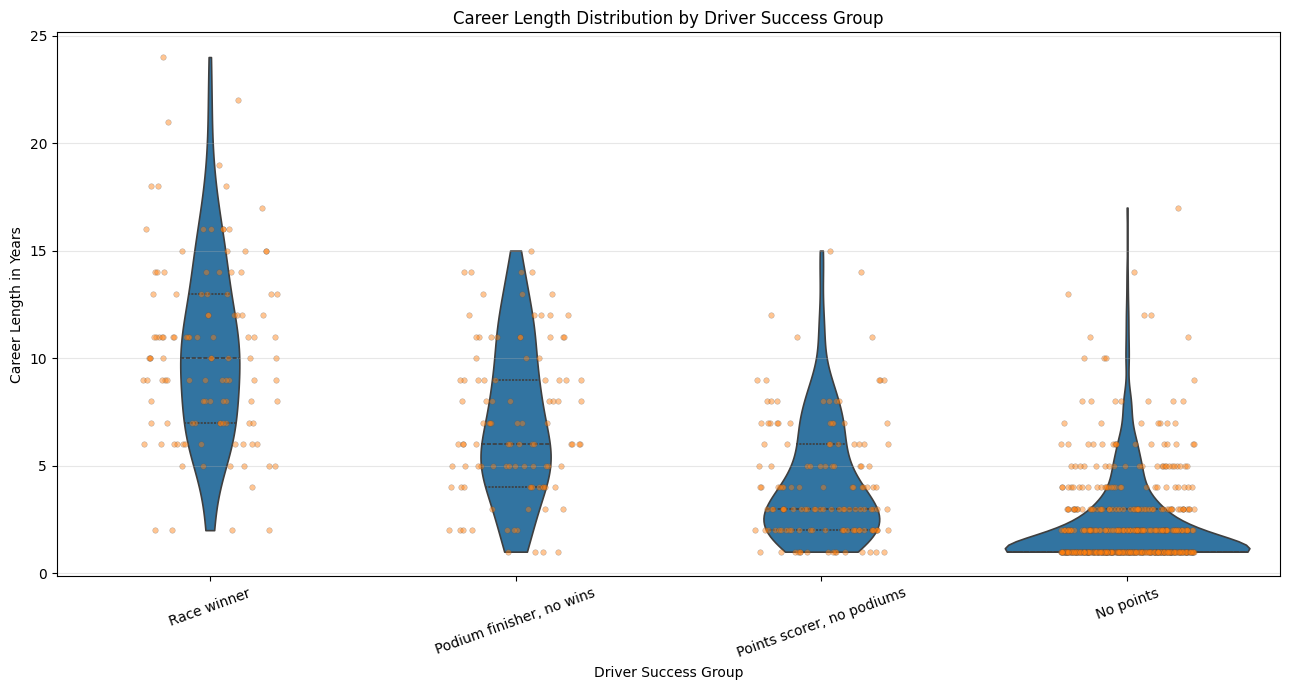

In [ ]:
violin_df = eda_df[
    ["driver_name", "success_group", "career_length_years", "race_winner"]
].dropna().copy()

success_order = [
    "Race winner",
    "Podium finisher, no wins",
    "Points scorer, no podiums",
    "No points"
]

violin_df = violin_df[
    violin_df["success_group"].isin(success_order)
].copy()

fig, ax = plt.subplots(figsize=(13, 7))

sns.violinplot(
    data=violin_df,
    x="success_group",
    y="career_length_years",
    order=success_order,
    inner="quartile",
    cut=0,
    linewidth=1.2,
    ax=ax
)

# add individual drivers as points.
sns.stripplot(
    data=violin_df,
    x="success_group",
    y="career_length_years",
    order=success_order,
    jitter=0.22,
    alpha=0.45,
    size=4,
    linewidth=0.3,
    ax=ax
)

ax.set_title("Career Length Distribution by Driver Success Group")
ax.set_xlabel("Driver Success Group")
ax.set_ylabel("Career Length in Years")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Again, we are seeing the same trends with longer careers and more success. The hierarchy of success falls in line with the trend of increasingly longer careers. Essentially, we can see that there is a relationship between winning a race and having a longer career.

Finally, we can look at the correlations between all of the features in order to understand the relationships they have. Here we are using Pandas' `.corr` function with the standard Pearson's correlation. We can then graph these in two different ways:


1.   A horizontal bar chart shows the relation between the features and the target variable. This is useful in determining which features are most correlated with a winning driver.
2.   A correlational heatmap shows the relationship between the different features. This is also useful for understanding the relationship between different features.





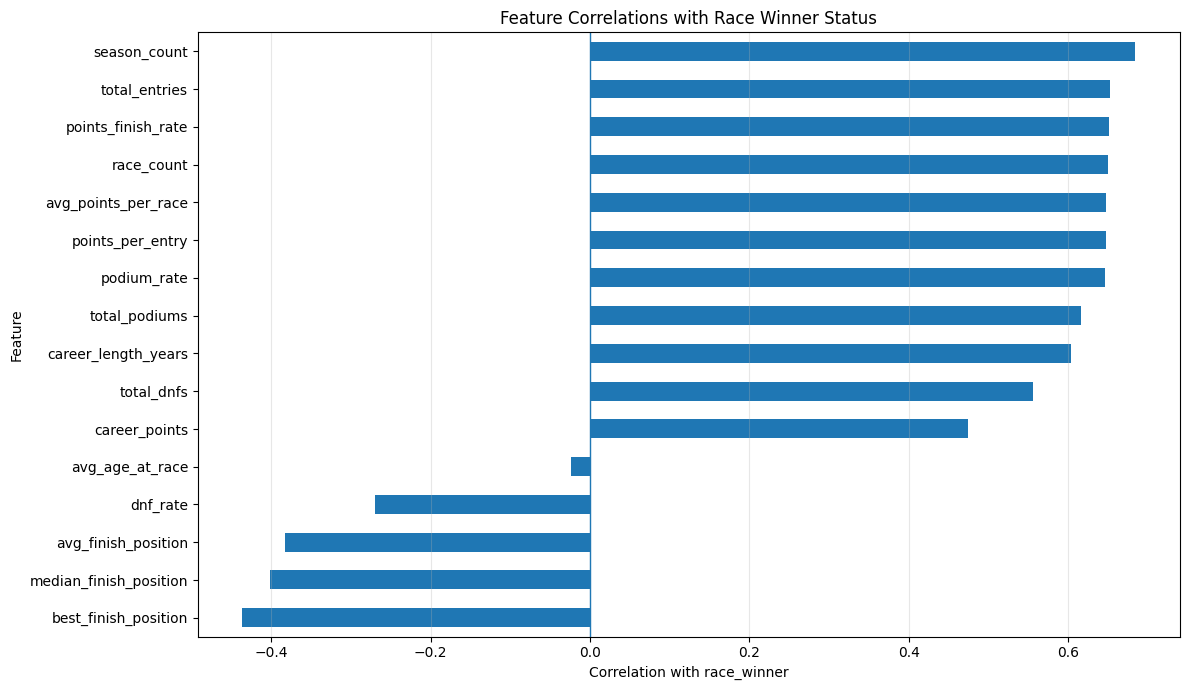

Correlational Heatmap:


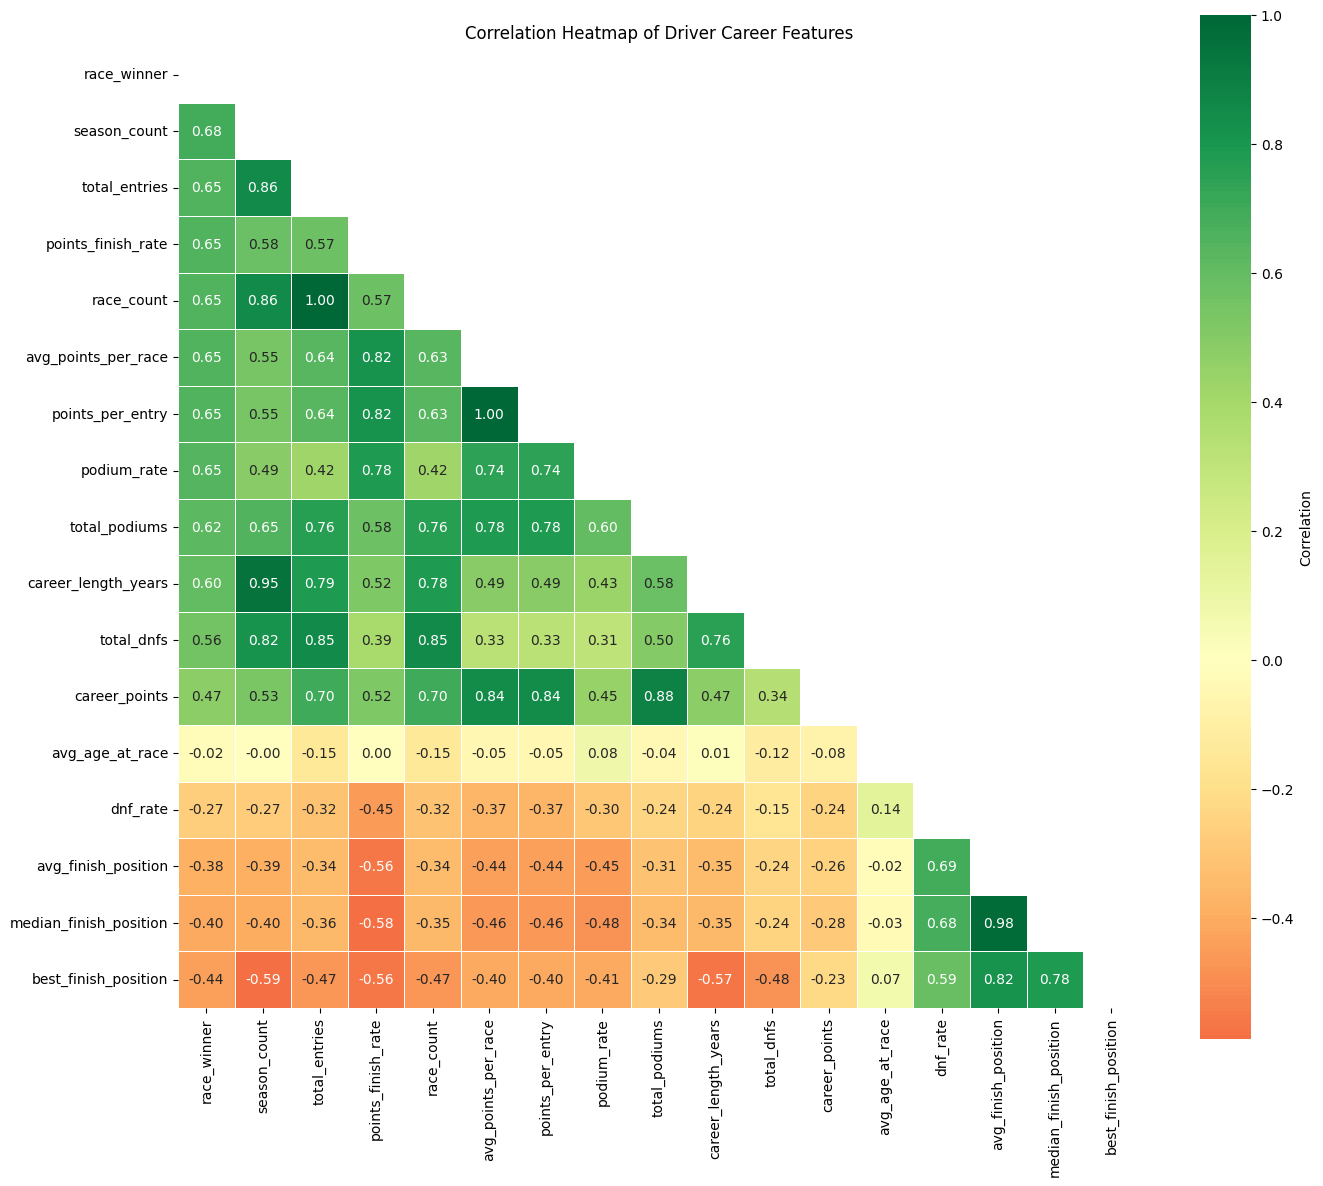

In [ ]:
# analyze correlations

correlation_features = [
    "race_winner",
    "career_length_years",
    "season_count",
    "total_entries",
    "race_count",
    "total_podiums",
    "career_points",
    "podium_rate",
    "points_finish_rate",
    "points_per_entry",
    "avg_points_per_race",
    "avg_finish_position",
    "median_finish_position",
    "best_finish_position",
    "total_dnfs",
    "dnf_rate",
    "avg_age_at_race"
]

corr_df = eda_df[correlation_features].copy()

target_correlations = (
    corr_df
    .corr(numeric_only=True)["race_winner"]
    .drop("race_winner")
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .to_frame(name="correlation_with_race_winner")
    .round(3)
)

# bar chart

fig, ax = plt.subplots(figsize=(12, 7))

target_correlations.sort_values("correlation_with_race_winner").plot(
    kind="barh",
    ax=ax,
    legend=False
)

ax.set_title("Feature Correlations with Race Winner Status")
ax.set_xlabel("Correlation with race_winner")
ax.set_ylabel("Feature")
ax.axvline(0, linewidth=1)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# correlation heatmap

print("Correlational Heatmap:")
full_corr = corr_df.corr(numeric_only=True)

sorted_index = full_corr['race_winner'].sort_values(ascending=False).index
corr_sorted = full_corr.loc[sorted_index, sorted_index]
mask = np.triu(np.ones_like(corr_sorted, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    corr_sorted,
    annot=True,
    mask=mask,
    fmt=".2f",
    linewidths=0.5,
    cmap="RdYlGn",
    center=0,
    square=True,
    cbar_kws={"label": "Correlation"},
    ax=ax
)

ax.set_title("Correlation Heatmap of Driver Career Features")

plt.tight_layout()
plt.show()

From this correlational heatmap, we can better visualize which features are closely correlated with `race_winner` and of these features, which features are also related with each other. Features such as `season_count`, `total_entries`, and `points_per_entry` are correlated with race winner. These features being correlated make sense for a race winner as we have seen previously with the observations of longer career and more points. `season_count` and `total_entries` are both closely related to the length of a driver's career and `points_per_entry` demonstrates that the driver consistently scores well in their races.

## **Primary Analysis**

Now we will perform a primary analysis on the data using machine learning.  Machine learning is a form of artificial intelligence that trains a model by having it take in training data, learn from the training data, and optimize itself based on the training data. The newly created model can now perform predictions after being given test data. Using machine learning will help us understand whether or not we can predict if a driver becomes a race winner based on their career statistics.

Based on the exploratory analysis we see that there are 12 important features that are correlated with race winners in this dataset. These features include the points finish rate, number of races, total number of entries, number of seasons, podium rate, career length, average number of points earned per race, number of points per entry, total number of podiums, number of races not finished, points earned throughout their careers and average age during a race. We will focus on using the top three most highly correlated features to train our models. Since our goal is to predict if a driver becomes a race winner based on their career statistics the machine learning techniques we will focus on is [classification](https://www.datacamp.com/blog/classification-machine-learning). After choosing a machine learning technique we now need to decide on what model(s) we will perform our analysis with. For this tutorial we will be utilizing two models, Support Vector Machine and Random Forest Classifier since both of these models are very useful when trying to classify data. We are testing both of these models, rather than one of them, to see if there is a significant difference between them because both perform classification using very different methods. Once we have finished training and testing both models, we will compare our results to understand which model is more reliable for identifying race winners and racers who have not won a race yet.

### **Support Vector Machine**

One of the machine learning models that we will use is a [Support Vector Machine](https://www.geeksforgeeks.org/machine-learning/support-vector-machine-algorithm/) (SVM). It is a machine learning algorithm that we can use for classification. We want to use it to understand if a Support Vector Machine is a good model for determining a race winner.  

To interpret our SVM's results we will be using `accuracy_score` and `classification_report`. Here is a breakdown explaining the key points to keep in mind when viewing the results:

*   **Accuracy**: the proportion of all classifications that were correct, regardless of whether they are positive or negative
*   **Precision**: the percentage of positive classifications made by a model that are actually positive
*   **Recall**: the percentage of the actual positives that were correctly classified as positive
*   **F1-Score**: the balance between the precision and recall

For further details on these items, please visit this [site](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall)

Here are what some of these items will represent in this dataset:

*   **Accuracy**: the proportion of all classifications that were correct, regardless of whether they are race winners or non-winners
*   **Precision**: the percentage of race winner classifications made by a model that are actually race winners
*   **Recall**: the percentage of the actual race winners that were correctly classified as race winners

In [ ]:
#Select the features with positive correlation
important_features = [
    "career_length_years",
    "season_count",
    "total_entries",
    "race_count",
    "total_podiums",
    "career_points",
    "podium_rate",
    "points_finish_rate",
    "points_per_entry",
    "avg_points_per_race",
    "total_dnfs",
    "avg_age_at_race"
]

important_df = eda_df[important_features].copy()
target_df = eda_df["race_winner"]

#Set the scaler
scaler = StandardScaler()
X = scaler.fit_transform(important_df)
y = target_df

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Linear Kernel
print("Linear Kernel")
#Fit the data onto the model
model1 = SVC(kernel="linear", probability=True, random_state=42)
model1.fit(X_train, y_train)

#Predict using test data
y_pred1 = model1.predict(X_test)

#Checking accuracy
accuracy = accuracy_score(y_test, y_pred1)
print(f"Accuracy: {accuracy}")

#Calculate the precision, recall, and f1 scores
report = classification_report(y_test, y_pred1)
print("Classification Report:\n", report)

Linear Kernel
Accuracy: 0.9710982658959537
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       155
           1       0.93      0.78      0.85        18

    accuracy                           0.97       173
   macro avg       0.95      0.89      0.92       173
weighted avg       0.97      0.97      0.97       173



The first kernel we used was "Linear". The precision and recall for race winners are 78% and 93%. This shows that the
model is capable of classifiying actual race winners with a mild false positive rate and low false negative rate. The balance between the race winners precision and recall, or F1-score, is 85%. For racers who did not win the precision and recall are much better, with precision at 97% and recall at 99%. This means that there is a low number of false positives and extremely low number of false negatives. The F1-score for non-winners is 98% which makes sense since the precision and recall are high while also being very close. So far, the results are solid but we are going to test other kernels to see if there is any improvement.

In [ ]:
#Polynomial Kernel
print("Polynomial Kernel")
#Fit the data onto the model
model2 = SVC(kernel="poly", probability=True, random_state=42)
model2.fit(X_train, y_train)

#Predict using test data
y_pred2 = model2.predict(X_test)

#Checking accuracy
accuracy = accuracy_score(y_test, y_pred2)
print(f"Accuracy: {accuracy}")

#Calculate the precision, recall, and f1 scores
report = classification_report(y_test, y_pred2)
print("Classification Report:\n", report)

Polynomial Kernel
Accuracy: 0.9710982658959537
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       155
           1       1.00      0.72      0.84        18

    accuracy                           0.97       173
   macro avg       0.98      0.86      0.91       173
weighted avg       0.97      0.97      0.97       173



The next kernel that we used was "Polynomial". The precision and recall for race winners are 100% and 72%, meaning this kernel supposedly has a 0% chance of incorrectly classifying racers who have not won as race winners. However, the recall is lower than the "Linear" kernel's recall, showing that this version of the model is more likely to have false negatives. The F1-score for race winners is 84%. The non-winner classification is about the same as the "Linear" kernel with precision being 97% and recall being 100%. The F1-score for non-winners is 98%. The overall results of this kernel show that "Linear" is currently the most reliable to use at the moment. We will still try the other two kernels to see if we can get even better results.

In [ ]:
#Sigmoid Kernel
print("Sigmoid Kernel")
#Fit the data onto the model
model3 = SVC(kernel="sigmoid", probability=True, random_state=42)
model3.fit(X_train, y_train)

#Predict using test data
y_pred3 = model3.predict(X_test)

#Checking accuracy
accuracy = accuracy_score(y_test, y_pred3)
print(f"Accuracy: {accuracy}")

#Calculate the precision, recall, and f1 scores
report = classification_report(y_test, y_pred3)
print("Classification Report:\n", report)

Sigmoid Kernel
Accuracy: 0.8554913294797688
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.90      0.92       155
           1       0.35      0.44      0.39        18

    accuracy                           0.86       173
   macro avg       0.64      0.67      0.65       173
weighted avg       0.87      0.86      0.86       173



The third kernel that we used was the "Sigmoid" kernel. The precision and recall for race winners are 35% and 44%, easily making this kernel the weakest of the three tested so far. The F1-score for race winners is 39%. The non-winner classification is a bit weaker than the previous two with precision being 93%, recall being 90%, and F1-score being 92%. These results show that the most reliable kernel is still "Linear" and that this kernel is especially weak for this datasdet. We will move on to the last kernel to see if the results will make it better than the "Linear" kernel.

In [ ]:
#Radial Basis Function Kernel
print("Radial Basis Function Kernel")
#Fit the data onto the model
model4 = SVC(kernel="rbf", probability=True, random_state=42)
model4.fit(X_train, y_train)

#Predict using test data
y_pred4 = model4.predict(X_test)

#Checking accuracy
accuracy = accuracy_score(y_test, y_pred4)
print(f"Accuracy: {accuracy}")

#Calculate the precision, recall, and f1 scores
report = classification_report(y_test, y_pred4)
print("Classification Report:\n", report)

Radial Basis Function Kernel
Accuracy: 0.9479768786127167
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       155
           1       0.74      0.78      0.76        18

    accuracy                           0.95       173
   macro avg       0.86      0.87      0.86       173
weighted avg       0.95      0.95      0.95       173



The final kernel that we used was is called the "Radial Basis Function" kernel (RBF). The precision and recall for race winners are 74% and 78%, maaking the F1-score for race winners is 76%. The precision and recall for non-winners are both 97%, making the F1-score for non-winners 97%. After testing all of the kernels we can see that the "Linear" kernel is the most optimal one to use for this dataset.

The plot below show us how closely the predicted probabilities of a racer being a winner are to the actual probabilities. For example, for a perfectly calibrated model, if it predicts a 0.7 probability the event should happen 70% of the time. All four kernels were plotted on one chart to show the similarities and differences shared between their predicted probabilities.

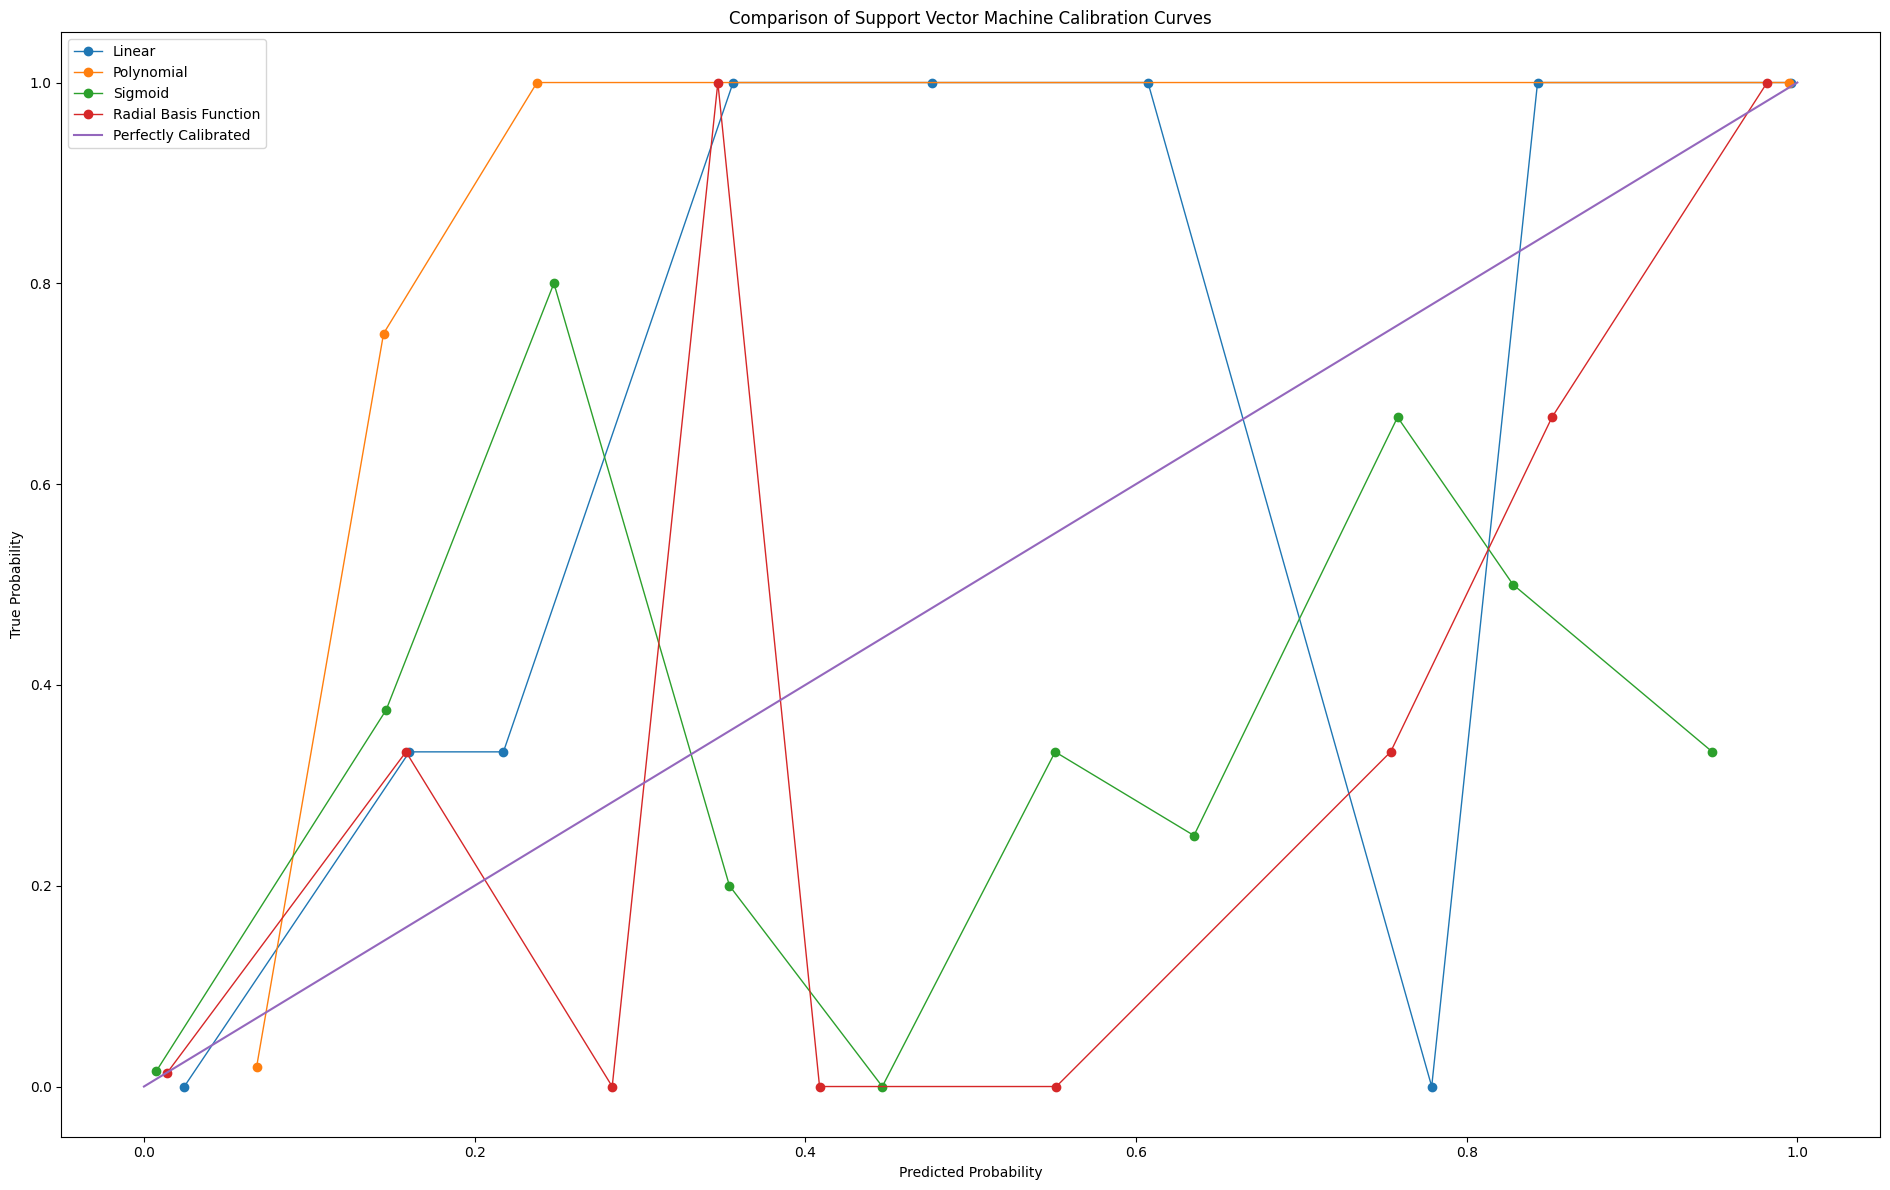

In [ ]:
y_prob1 = model1.predict_proba(X_test)
y_prob2 = model2.predict_proba(X_test)
y_prob3 = model3.predict_proba(X_test)
y_prob4 = model4.predict_proba(X_test)

true_pos1, pred_pos1 = calibration_curve(y_test, y_prob1[:, 1], n_bins=10)
true_pos2, pred_pos2 = calibration_curve(y_test, y_prob2[:, 1], n_bins=10)
true_pos3, pred_pos3 = calibration_curve(y_test, y_prob3[:, 1], n_bins=10)
true_pos4, pred_pos4 = calibration_curve(y_test, y_prob4[:, 1], n_bins=10)

# Plot the Calibration Display
fig, ax = plt.subplots(figsize=(19, 12))

plt.plot(pred_pos1, true_pos1, marker='o', linewidth=1, label='Linear')
plt.plot(pred_pos2, true_pos2, marker='o', linewidth=1, label='Polynomial')
plt.plot(pred_pos3, true_pos3, marker='o', linewidth=1, label='Sigmoid')
plt.plot(pred_pos4, true_pos4, marker='o', linewidth=1, label='Radial Basis Function')

plt.plot([0, 1], [0, 1], label='Perfectly Calibrated')
plt.xlabel('Predicted Probability')
plt.ylabel('True Probability')
plt.legend()
plt.title("Comparison of Support Vector Machine Calibration Curves")
plt.tight_layout()
plt.show()

### Random Forest Classifier

The second model we will use is a Random Forest Classifier.
A Random Forest works by building a bunch of decision trees and combining their results to make a final prediction.  We chose this model because our dataset has a lot more non-winners than winners, and Random Forest handles that imbalance better than SVM. It also gives us feature importances for free, which will be useful when we want to understand which career stats actually matter for predicting a race winner.

In [ ]:
# Train Random Forest using the same train/test split as SVM
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_test)

# Metrics
rf_accuracy = accuracy_score(y_test, rf_preds)
print(f"Accuracy: {rf_accuracy}")
print("Classification Report:\n", classification_report(y_test, rf_preds, target_names=["Non-winner", "Race winner"]))

Accuracy: 0.9710982658959537
Classification Report:
               precision    recall  f1-score   support

  Non-winner       0.98      0.99      0.98       155
 Race winner       0.88      0.83      0.86        18

    accuracy                           0.97       173
   macro avg       0.93      0.91      0.92       173
weighted avg       0.97      0.97      0.97       173



The Random Forest came in at 96% accuracy. Looking at the classification report, it does a great job identifying
non-winners (98% precision, 97% recall), which makes sense given how many more non-winners there are in the dataset.
For race winners specifically, it hits 79% precision and 83% recall, so it correctly identifies most actual winners, but it does occasionally misclassify a winner as a non-winner. Overall these numbers are strong, and we can compare
them against our SVM to see which model handles the class imbalance better.

Below we can also see the confusion matrix as well as which features the
Random Forest leaned on the most when making its predictions.

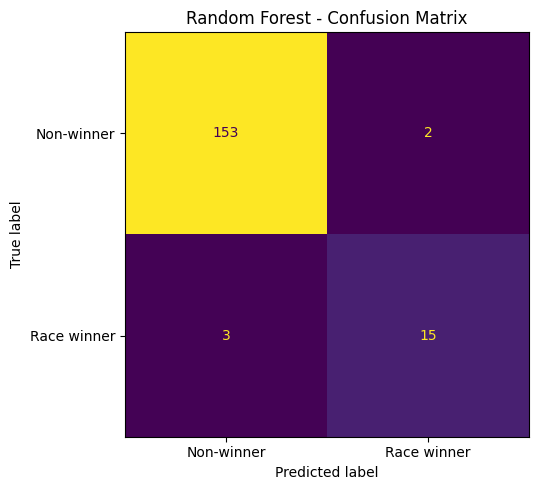

In [ ]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_preds,
    display_labels=["Non-winner", "Race winner"],
    ax=ax,
    colorbar=False
)
ax.set_title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

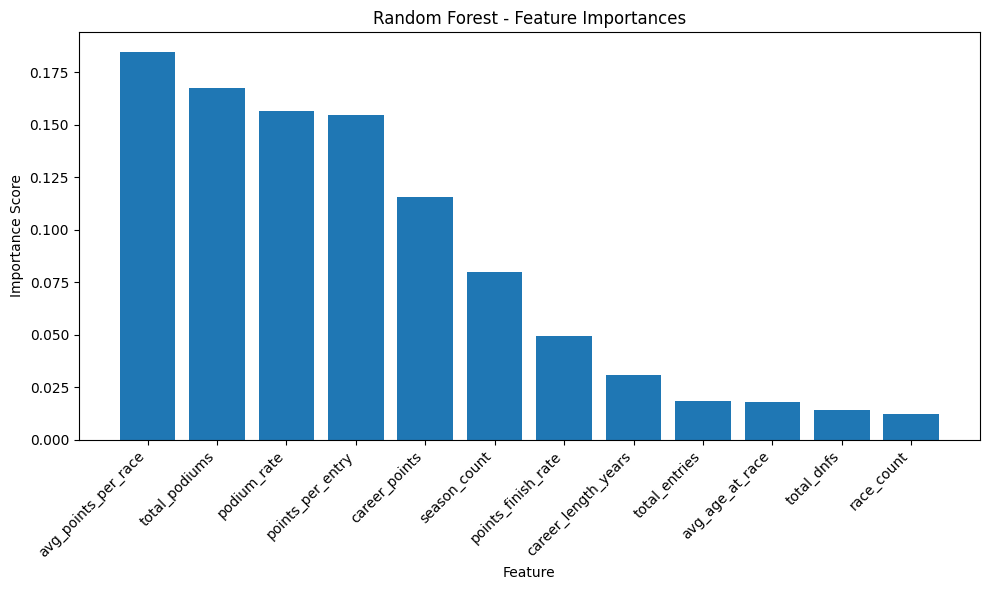

In [ ]:
# Feature Importance Chart
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(len(importances)), importances[indices])
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([important_features[i] for i in indices], rotation=45, ha="right")
ax.set_title("Random Forest - Feature Importances")
ax.set_xlabel("Feature")
ax.set_ylabel("Importance Score")
plt.tight_layout()
plt.show()

The feature importance chart gives us a good picture of what separates race winners from non-winners.
`avg_points_per_race` and `total_podiums` are the two most important features by a decent margin, which is logical as drivers who regulary score points and finish on the podium are most likely to win a race. Then, `career_points` and `points_per_entry` follow closely behind, reinforcing that
overall consistency is a bigger indicator of success than career length alone.

Looking at the confusion matrix, out of 18 actual race winners in the test set the model correctly identified 15 of them, only misclassifying 3 as non-winners. On the non-winner side it misclassified 2 out of 153,
which is very low. Overall the Random Forest handles the class imbalance well and gives us more interpretability than the SVM through these feature importances.

### Primary Analysis Conclusion



After trying four different kernels with our Support Vector Machine model, we found that the "Linear" kernel was the most reliable when classifying racers. The "Linear" kernel had a non-winner precision and recall of 97% and 99%, winner precision and recall of 93% and 78%, and F1-scores of 98% for non-winners and 85 for winners. The overall accuracy of this kernel was 97%. Next, we trained and tested a Random Forest Classifier model and got similar results to our SVM. The precision and recall for non-winners were 98% and 99%. The precision and recall for winners were 88% and 83%. The F1-score for non-winners was 98% and F1-score for winners was 86%, with an overall accuracy of 97%. Overall, both models were very effective when it came to classifying racers but the Random Forest Classifier model is slightly better. Since our dataset is somewhat unbalanced we will focus more on their F1-scores rather than their accuracies. The non-winner F1-scores for both were identical, but the winner F1-score for Random Forest outperformed our SVM by 1%. From this analysis we have learned that it is possible to predict whether a driver becomes is a race winner based on their career statistics and that the Random Forest Classifier model is the best to do so.

## **Visualization**

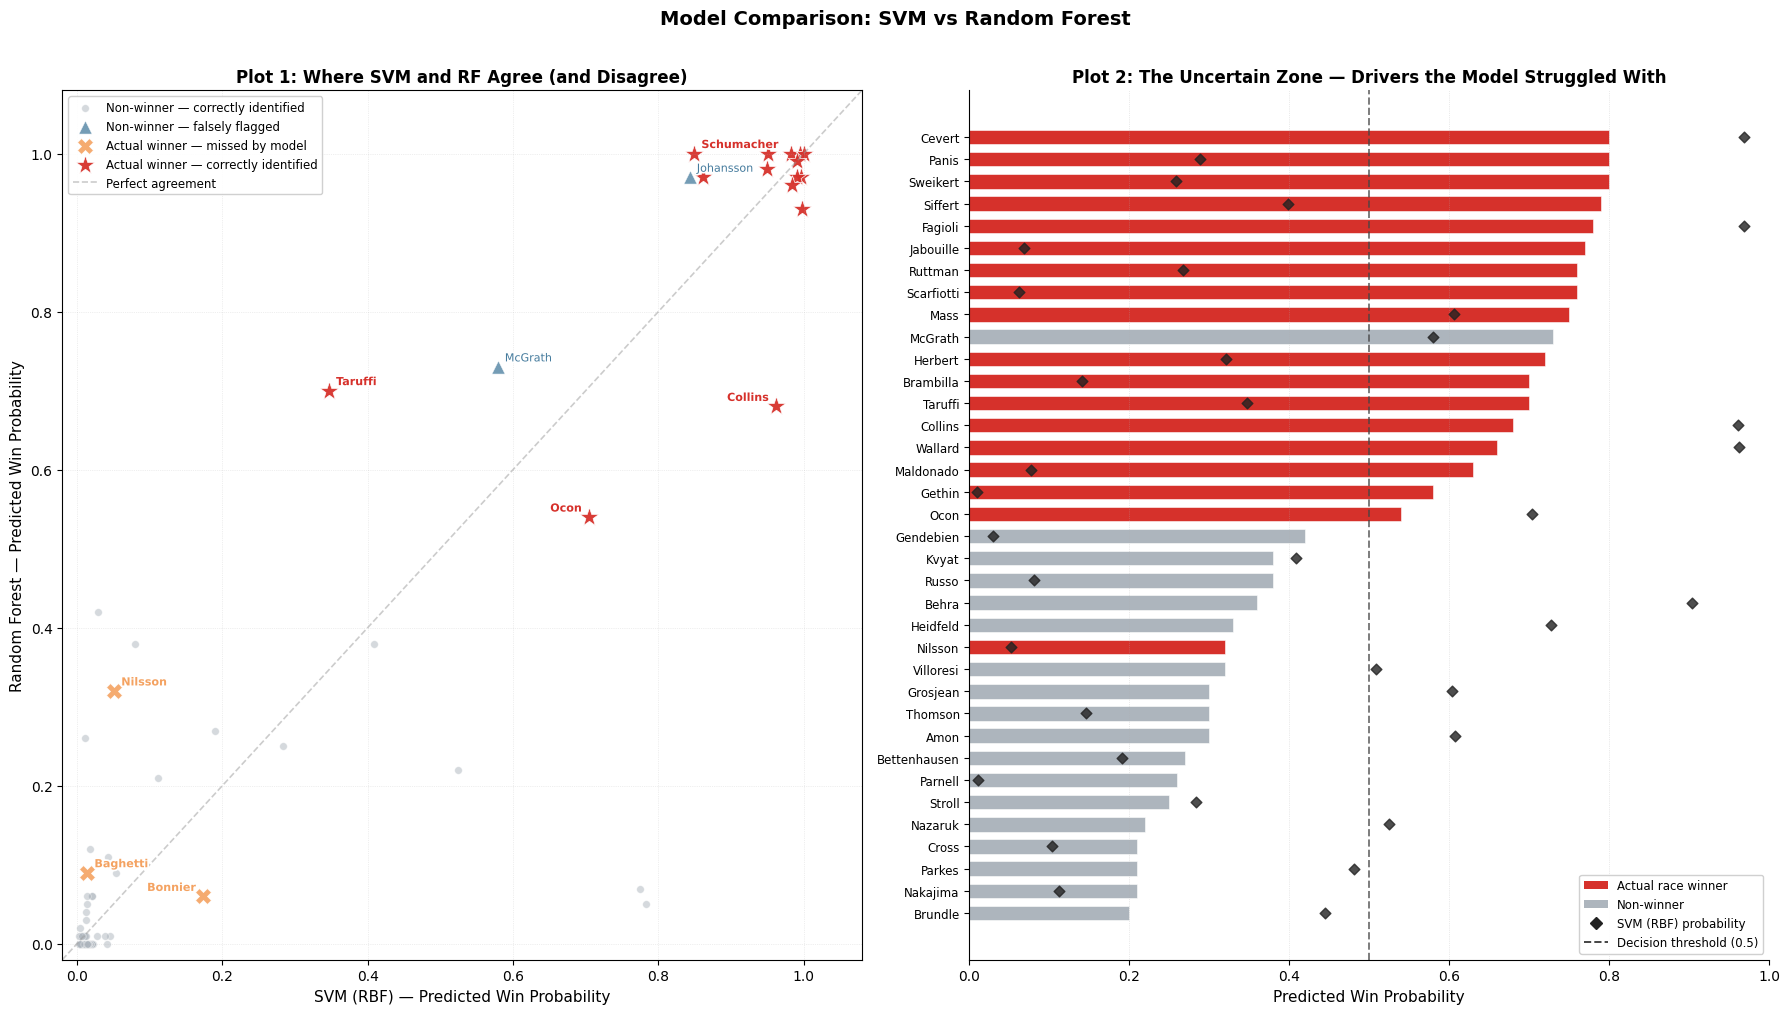

In [ ]:
svm_probs = model4.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]
test_idx = y_test.index
driver_names = eda_df.loc[test_idx, "driver_name"].values
actual_winner = y_test.values

COLORS = {
    "TP": "#d6312b", "FN": "#f4a261",
    "FP": "#457b9d", "TN": "#adb5bd",
}

def classify(svm_p, rf_p, actual):
    pred = int((svm_p + rf_p) / 2 >= 0.5)
    if actual == 1 and pred == 1: return "TP"
    if actual == 1 and pred == 0: return "FN"
    if actual == 0 and pred == 1: return "FP"
    return "TN"

cats = [classify(s, r, a) for s, r, a in zip(svm_probs, rf_probs, actual_winner)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle("Model Comparison: SVM vs Random Forest", fontsize=14, fontweight="bold", y=1.01)

##### ---- Plot 1
legend_labels = {
    "TP": "Actual winner — correctly identified",
    "FN": "Actual winner — missed by model",
    "FP": "Non-winner — falsely flagged",
    "TN": "Non-winner — correctly identified",
}
#set sizes, shapes, opacity
markers = {"TP": "*", "FN": "X", "FP": "^", "TN": "o"}
sizes   = {"TP": 200, "FN": 130, "FP": 90, "TN": 30}
alphas  = {"TP": 0.95, "FN": 0.9, "FP": 0.75, "TN": 0.5}

for cat in ["TN", "FP", "FN", "TP"]:
    mask = np.array([c == cat for c in cats])
    ax1.scatter(svm_probs[mask], rf_probs[mask],
                c=COLORS[cat], marker=markers[cat], s=sizes[cat],
                alpha=alphas[cat], edgecolors="white", linewidths=0.5,
                label=legend_labels[cat])

#add labels to names that stand out
for i, (cat, name) in enumerate(zip(cats, driver_names)):
    disagreement = abs(svm_probs[i] - rf_probs[i])
    if cat in ("FN", "FP") or (cat == "TP" and disagreement > 0.15):
        dx = 5 if rf_probs[i] >= svm_probs[i] else -5
        ax1.annotate(name.split(" ")[-1], (svm_probs[i], rf_probs[i]),
                     fontsize=8, fontweight="bold" if cat in ("FN", "TP") else "normal",
                     xytext=(dx, 4), textcoords="offset points",
                     ha="left" if dx > 0 else "right", color=COLORS[cat],
                     path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

lims = [-0.02, 1.08]
ax1.plot(lims, lims, "--", color="#999999", linewidth=1.2, alpha=0.5, label="Perfect agreement")
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_xlabel("SVM (RBF) — Predicted Win Probability", fontsize=11)
ax1.set_ylabel("Random Forest — Predicted Win Probability", fontsize=11)
ax1.set_title("Plot 1: Where SVM and RF Agree (and Disagree)", fontsize=12, fontweight="bold")
ax1.legend(fontsize=8.5, framealpha=0.92, edgecolor="#cccccc", loc="upper left")
ax1.grid(True, linestyle=":", linewidth=0.5, alpha=0.4)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}"))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}"))


#Plot 2----
X_all = scaler.transform(eda_df[important_features])
rf_all = np.clip(rf_model.predict_proba(X_all)[:, 1], 0, 1)
svm_all = np.clip(model4.predict_proba(X_all)[:, 1], 0, 1)
all_names = eda_df["driver_name"].values
all_actual = eda_df["race_winner"].values

#get only uncertain ones
uncertain_mask = (rf_all >= 0.2) & (rf_all <= 0.8)
u_prob = rf_all[uncertain_mask]
u_names = all_names[uncertain_mask]
u_actual = all_actual[uncertain_mask]
u_svm  = svm_all[uncertain_mask]

order  = np.argsort(u_prob)
u_prob = u_prob[order]
u_names = u_names[order]
u_actual = u_actual[order]
u_svm  = u_svm[order]

y_pos    = np.arange(len(u_prob))
bar_cols = [COLORS["TP"] if a == 1 else COLORS["TN"] for a in u_actual]

ax2.barh(y_pos, u_prob, color=bar_cols, edgecolor="white", linewidth=0.4, height=0.65)
ax2.scatter(u_svm, y_pos, color="#222222", s=30, zorder=5, marker="D", alpha=0.8)
ax2.axvline(0.5, color="#444", linewidth=1.4, linestyle="--", alpha=0.7)

ax2.set_yticks(y_pos)
ax2.set_yticklabels([n.split(" ")[-1] for n in u_names], fontsize=8.5)
ax2.set_xlabel("Predicted Win Probability", fontsize=11)
ax2.set_title("Plot 2: The Uncertain Zone — Drivers the Model Struggled With",
              fontsize=12, fontweight="bold")
ax2.set_xlim(0, 1.0)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}"))
ax2.grid(True, axis="x", linestyle=":", linewidth=0.5, alpha=0.5)
ax2.spines[["top", "right"]].set_visible(False)
ax2.legend(handles=[
    Patch(facecolor=COLORS["TP"], label="Actual race winner"),
    Patch(facecolor=COLORS["TN"], label="Non-winner"),
    plt.Line2D([0],[0], marker="D", color="#222", markersize=6,
               linestyle="None", label="SVM (RBF) probability"),
    plt.Line2D([0],[0], color="#444", linewidth=1.4,
               linestyle="--", label="Decision threshold (0.5)"),
], fontsize=8.5, framealpha=0.92, edgecolor="#cccccc", loc="lower right")

plt.tight_layout()
plt.show()

Plot 1 — SVM vs Random Forest Agreement

Each point is a driver from the test set, plotted by the probability each model assigned them. Points along the dashed diagonal agreed on by both models. The further a point sits from the line, the more they disagreed. Named drivers like Taruffi, Collins, and Nilsson are cases where the two models gave meaningfully different estimates. The dense cluster in the corners shows strong agreement on the clear-cut cases.

Many of the labeled drivers are interesting cases, such as Giancarlo Baghetti, who won in his first race ever and never again. Interestingly, Piero Taruffi also only won one race. He had a relatively short career with few total entries, so his raw career numbers (total podiums, career points) were low, exactly the kind of features the SVM's linear boundary leans on heavily. But his rate statistics were decent for his era (when he finished, he scored points). The Random Forest, which can combine features non-linearly, likely captured that his podium rate and points-per-entry were disproportionately high relative to his career length, and weighted that combination toward a winner. The SVM drew a straight line in feature space and his raw totals pulled him toward the non-winner side of it.
Peter Collins is almost the reverse story, having low efficiency but large volume.

To summarize, the difference between the two models that this chart exposes: SVM rewards career volume and RF rewards per-race efficiency. Early-era drivers with short but efficient careers will almost always score higher with RF than SVM for exactly this reason.

----------------


Plot 2 — The Uncertain Zone

Focuses on drivers where RF probability fell between 0.2 and 0.8. Bars = RF probability, diamonds = SVM probability, dashed line = decision threshold at 0.5. Red bars left of the threshold are actual winners the model underestimated. Many are early-era F1 drivers whose avg_points_per_race looks low by modern standards due to the historical points system changes, which is exactly the domain knowledge bias flagged in the insights section.

Some interesting cases here:
Jabouille won twice but had a short career with thin raw totals. The SVM saw low volume and assigned near-zero probability. The RF read his per-race efficiency correctly and rated him a likely winner, so the SVM was fooled by career length, the RF wasn't.
Behra never won a race despite a long 1950s career with strong aggregate numbers. The SVM's linear boundary put him firmly in winner territory. The RF detected that his efficiency metrics didn't match actual winners and pulled back. THis is a classic SVM false positive.

## **Insights and Conclusions**

After reading through the project, an uninformed reader would have a much better understanding of factors that contribute to success in Formula 1 and how machine learning concepts can be applied to historical sports data. Throughout the analyis, we explored how variables such as podium rate, DNF percentage and career efficiency contribute to a driver's ability to win races. We combined data analysis, hypothesis testing, and predictive modeling to identify trends that separate winning drivers from non-winning drivers.

One breakthrough finding from this project was how different models interpreted driver success. The Support Vector Machine tended to favor drivers with long careers and high stats, while the Random Forest model was better at identifying drivers with shorter but more successful careers. The differences were evidenced in the visual section where different drivers received different probability estimates based on the model's interpretations. This distinction also showed that success in Formula 1 is not necessarily linear and factors such as time period and competition also play a role in determining success.

Speaking of time periods, the project also highlights challenges in analyzing Formula 1 data, since scoring systems, race formats, and season lengths have changed drastically over the course of the sport. Therefore, preprocessing and feature engineering were essential in ensuring fair comparisons across eras.

Our hypothesis was that historical driver statistics could be used to predict success in Formula 1. Based on the performance of the machine learning models, the results proved our hypothesis, showing that the models were able to identify a pattern between driver statistics and success.

Overall, the models achieved strong predictive analyses and showed how data science can be applied to identify patterns that may not be found through standard means.